### (260814제출)웹스크랩핑 연습문제
##### 개발 6기 구본영
#### 목차
##### 4. 웹스크래핑 연습문제 4
###### 4-1. 인구현황 데이터 분석
###### 1.   지역별 총인구수 Top5
###### 1-1. 지역별 총인구수 plot
###### 2.   세대당 인구수 높은 지역 Top5
###### 2-1. 지역별 세대당 인구 Plot
###### 3.   남녀 비율 분석
###### 3-1. 남녀 비율 분석 Plot
###### 4.   남자초과 / 여자초과 분석
###### 5.   세대당 인구 평균보다 높은 지역
###### 5-1. 남초 vs 여초 개수 Plot  (seaborn의 countplot)
######      지역별 세대수 Plot (seaborn의 barplot)

### 4-1. 인구현황 데이터 분석
#### data/인구현황.csv 사용
#### 1. 지역별 총인구수 Top5


In [3]:
import pandas as pd
print(pd.__version__)

data=pd.read_csv('../data/인구현황.csv') #CSV 파일 읽기
print(data.shape) #행과 열 갯수를 튜플로 보여줌
print(type(data)) #<class 'pandas.core.frame.DataFrame'>


2.2.2
(18, 8)
<class 'pandas.core.frame.DataFrame'>


In [4]:
top5_pop=data.loc[data['행정기관'] != '전국', ['행정기관','총인구수']]\
    .sort_values(by='총인구수',ascending=False)

top5_pop.head(5)

,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


#### 1-1. 지역별 총인구수 plot

In [5]:
%matplotlib inline

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

print('matplotlib ', matplotlib.__version__)
print('seaborn ', sns.__version__)

# for font in fm.fontManager.ttflist:
#     print((font.name, font.fname))
# 폰트이름과 폰트파일 정보 출력 list comprehension 
[ (font.name, font.fname) for font in fm.fontManager.ttflist if 'Mal' in font.name ]

# font name을 알고 있다면 생략가능
#한글폰트 path 설정
font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
#font의 파일정보로 font name 을 알아내기
font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)

# matplotlib의 rc(run command) 함수를 사용해서 font name(Malgun Gothic) 설정
matplotlib.rc('font', family=font_name)

matplotlib  3.9.2
seaborn  0.13.2
Malgun Gothic


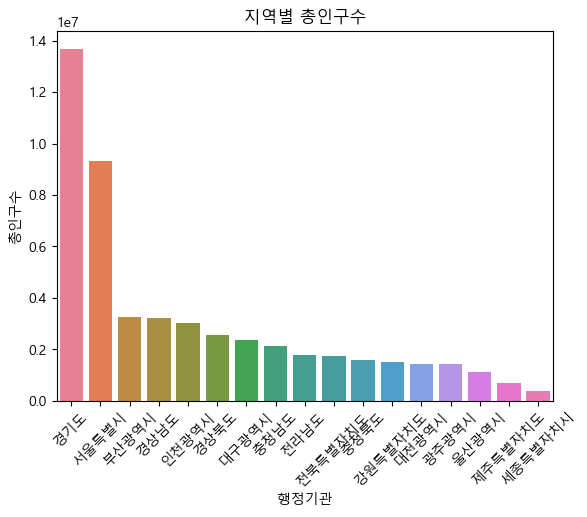

In [7]:
sns.barplot(data=top5_pop,x='행정기관',y='총인구수',hue="행정기관")

plt.xticks(rotation=45)
plt.title('지역별 총인구수')
plt.show()

#### 2. 세대당 인구수 높은 지역 Top5

In [8]:
data

,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
0,1000000000,전국,51217221,24118928,2.12,25498324,25718897,0.99
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00
5,2900000000,광주광역시,1408422,658075,2.14,695224,713198,0.97
6,3000000000,대전광역시,1439157,687757,2.09,717291,721866,0.99
7,3100000000,울산광역시,1098049,495378,2.22,564888,533161,1.06
8,3600000000,세종특별자치시,390685,163432,2.39,194413,196272,0.99
9,4100000000,경기도,13694685,6058202,2.26,6882186,6812499,1.01


In [9]:
top5_region=data.loc[data['행정기관']!='전국',['행정기관','세대당 인구']]\
                    .sort_values(by='세대당 인구',ascending=False).reset_index(drop=True)

top5_region.head(5)


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


#### 2-1. 지역별 세대당 인구 Plot

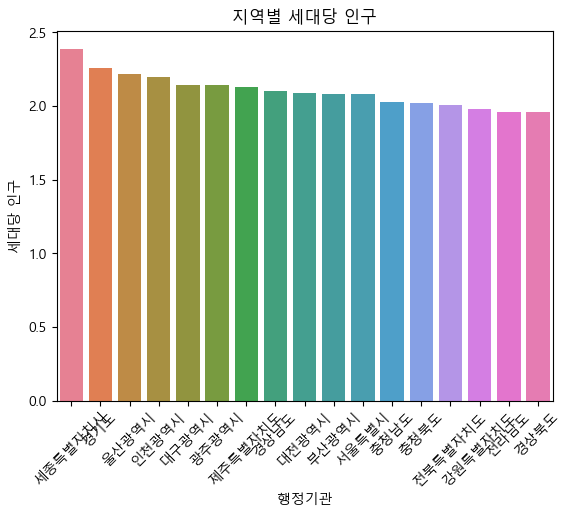

In [10]:
sns.barplot(data=top5_region,x='행정기관',y='세대당 인구',hue="행정기관")

plt.xticks(rotation=45)
plt.title('지역별 세대당 인구')
plt.show()

#### 3. 남녀 비율 분석

In [11]:
data

,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
0,1000000000,전국,51217221,24118928,2.12,25498324,25718897,0.99
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00
5,2900000000,광주광역시,1408422,658075,2.14,695224,713198,0.97
6,3000000000,대전광역시,1439157,687757,2.09,717291,721866,0.99
7,3100000000,울산광역시,1098049,495378,2.22,564888,533161,1.06
8,3600000000,세종특별자치시,390685,163432,2.39,194413,196272,0.99
9,4100000000,경기도,13694685,6058202,2.26,6882186,6812499,1.01


In [12]:
gender_ratio=data.loc[data['행정기관']!='전국',['행정기관','남여 비율']]\
                    .sort_values(by='남여 비율',ascending=False).reset_index(drop=True)
gender_ratio

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


#### 3-1. 남녀 비율 분석 Plot

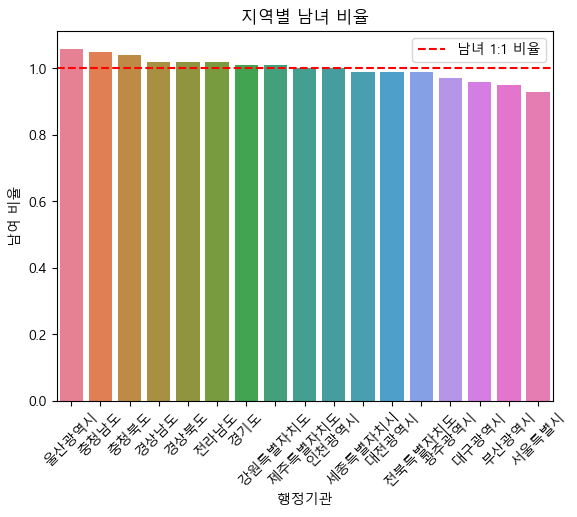

In [13]:
sns.barplot(data=gender_ratio,x='행정기관',y='남여 비율',hue='행정기관')

plt.xticks(rotation=45)
plt.axhline(y=1.0,color='red',linestyle='--',label='남녀 1:1 비율')
plt.legend()
plt.title('지역별 남녀 비율')
plt.show()

#### 4. 남자초과 / 여자초과 분석

In [14]:
data


,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
0,1000000000,전국,51217221,24118928,2.12,25498324,25718897,0.99
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00
5,2900000000,광주광역시,1408422,658075,2.14,695224,713198,0.97
6,3000000000,대전광역시,1439157,687757,2.09,717291,721866,0.99
7,3100000000,울산광역시,1098049,495378,2.22,564888,533161,1.06
8,3600000000,세종특별자치시,390685,163432,2.39,194413,196272,0.99
9,4100000000,경기도,13694685,6058202,2.26,6882186,6812499,1.01


In [15]:
import numpy as np

data_copy=data.copy()
data_copy['남초여초'] = np.where(data['남여 비율'] > 1.0,'남초',       
                            np.where(data['남여 비율'] < 1.0,'여초','동일'))

data_copy

,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율,남초여초
0,1000000000,전국,51217221,24118928,2.12,25498324,25718897,0.99,여초
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93,여초
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95,여초
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96,여초
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00,동일
5,2900000000,광주광역시,1408422,658075,2.14,695224,713198,0.97,여초
6,3000000000,대전광역시,1439157,687757,2.09,717291,721866,0.99,여초
7,3100000000,울산광역시,1098049,495378,2.22,564888,533161,1.06,남초
8,3600000000,세종특별자치시,390685,163432,2.39,194413,196272,0.99,여초
9,4100000000,경기도,13694685,6058202,2.26,6882186,6812499,1.01,남초


In [16]:

gender_over=data_copy.loc[data['행정기관']!='전국',['행정기관','남여 비율','남초여초']]\
                    .reset_index(drop=True)
gender_over.index = gender_over.index + 1

gender_over

,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


#### 5. 세대당 인구 평균보다 높은 지역

In [23]:
data

pop_mean_value=data['세대당 인구'].mean()

pop_mean_gt = data.loc[(data['행정기관'] != '전국') & (data['세대당 인구'] > pop_mean_value), ['행정기관','세대당 인구']].copy()\
                    .sort_values(by=['세대당 인구'],ascending=False)\
                    .reset_index(drop=True)

pop_mean_gt

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


#### 5-1. 남초 vs 여초 개수 Plot  ( seaborn의 countplot )
####         지역별 세대수 Plot ( seaborn의 barplot )

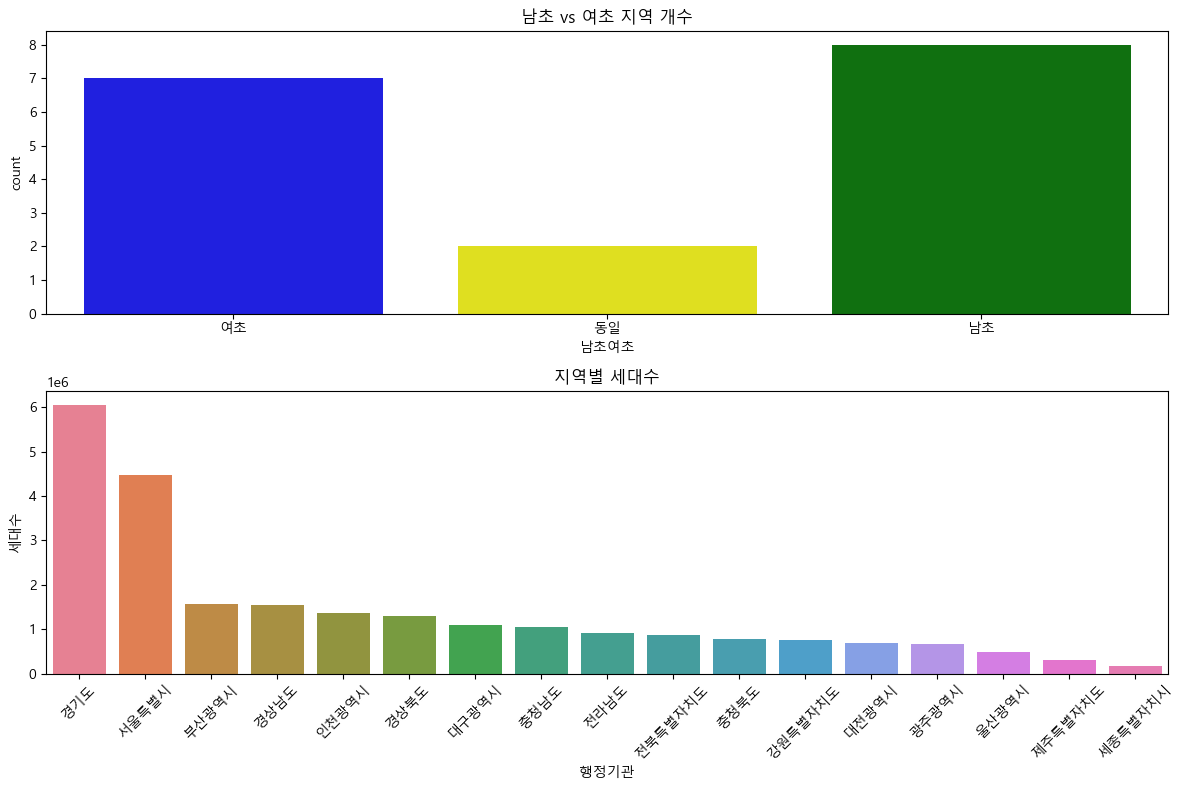

In [ ]:
region_data = data_copy.loc[data_copy['행정기관'] != '전국'].copy()
house_count = region_data.sort_values(by='세대수',ascending=False)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 1. 남초 vs 여초 개수
sns.countplot(
    data=region_data,
    x='남초여초',
    hue='남초여초',
    order=['여초', '동일', '남초'],
    palette={
        '여초': 'blue',
        '동일': 'yellow',
        '남초': 'green'
    },
    legend=False,
    ax=axes[0]
)

axes[0].set_title('남초 vs 여초 지역 개수')
axes[0].set_xlabel('남초여초')
axes[0].set_ylabel('count')


# 2. 지역별 세대수
sns.barplot(
    data=house_count,
    x='행정기관',
    y='세대수',
    hue="행정기관",
    ax=axes[1]
)

axes[1].set_title('지역별 세대수')
axes[1].set_xlabel('행정기관')
axes[1].set_ylabel('세대수')
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()



#### 끝. 감사합니다.